# Flood Risk EDA — Water Level + Reservoir Volume

This notebook loads the NVE HydAPI output and prepares EDA for both:

- `water_level` / parameter `1000`
- `reservoir_volume` / parameter `1004`

It supports two input formats:

1. **Wide format**: `timestamp, water_level, reservoir_volume`
2. **Long format**: `timestamp, value, feature_name`

Use the wide file for modelling.

In [43]:
# ============================================================
# 1. Imports
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [44]:
# ============================================================
# 2. Configuration
# ============================================================

DATE_COL = "timestamp"
TARGET_COL = "water_level"
RESERVOIR_COL = "reservoir_volume"

# Add/remove paths depending on where you run the notebook from.
WIDE_PATH_CANDIDATES = [

    "../src/data/raw/nve_observations_wide.csv",
]

LONG_PATH_CANDIDATES = [

    "../src/data/raw/nve_observations_long.csv",

]

PROCESSED_OUTPUT_CANDIDATES = [
    "../src/data/processed/nve_observations_wide_clean.csv",

]

In [45]:
# ============================================================
# 3. Helper functions
# ============================================================

def first_existing_path(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None


def load_nve_data():
    """Load wide data if available. If not, load long data and pivot to wide."""
    wide_path = first_existing_path(WIDE_PATH_CANDIDATES)

    if wide_path is not None:
        print("Loading wide data from:", wide_path)
        data = pd.read_csv(wide_path)
        data.columns.name = None
        return data, wide_path

    long_path = first_existing_path(LONG_PATH_CANDIDATES)

    if long_path is None:
        raise FileNotFoundError(
            "Could not find NVE data. Expected one of these wide paths:\n"
            + "\n".join(WIDE_PATH_CANDIDATES)
            + "\n\nOr one of these long paths:\n"
            + "\n".join(LONG_PATH_CANDIDATES)
        )

    print("Loading long data from:", long_path)
    long_df = pd.read_csv(long_path)

    required = {DATE_COL, "feature_name", "value"}
    missing = required - set(long_df.columns)
    if missing:
        raise ValueError(f"Long data is missing required columns: {missing}")

    data = (
        long_df
        .pivot_table(
            index=DATE_COL,
            columns="feature_name",
            values="value",
            aggfunc="mean"
        )
        .reset_index()
        .sort_values(DATE_COL)
    )

    data.columns.name = None
    return data, long_path


def save_clean_data(data):
    for out_path in PROCESSED_OUTPUT_CANDIDATES:
        out_dir = os.path.dirname(out_path)
        try:
            os.makedirs(out_dir, exist_ok=True)
            data.to_csv(out_path, index=False)
            print("Saved clean wide data to:", out_path)
            return out_path
        except Exception as e:
            print("Could not save to", out_path, "|", e)

    print("Clean data was not saved.")
    return None

In [46]:
# ============================================================
# 4. Load data
# ============================================================

df, source_path = load_nve_data()

print("Raw shape:", df.shape)
print("Raw columns:", df.columns.tolist())
display(df.head())

Loading wide data from: ../src/data/raw/nve_observations_wide.csv
Raw shape: (42776, 3)
Raw columns: ['timestamp', 'reservoir_volume', 'water_level']


,timestamp,reservoir_volume,water_level
0,2020-12-13 12:00:00+00:00,9.220051,79.12000
1,2020-12-13 13:00:00+00:00,9.233793,79.12125
2,2020-12-13 14:00:00+00:00,9.316249,79.12875
3,2020-12-13 15:00:00+00:00,9.329991,79.13000
4,2020-12-13 16:00:00+00:00,9.343745,79.13125


In [47]:
# ============================================================
# 5. Clean data
# ============================================================

df = df.copy()

if DATE_COL not in df.columns:
    raise ValueError(f"Missing timestamp column: {DATE_COL}. Available columns: {df.columns.tolist()}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce", utc=True)
df = df.dropna(subset=[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

# Remove metadata columns if they appear accidentally.
metadata_cols = [
    "station_id", "stationId", "parameter", "resolution_time",
    "quality", "feature_name", "unit"
]
df = df.drop(columns=[c for c in metadata_cols if c in df.columns], errors="ignore")

# Convert all non-date columns to numeric.
for col in df.columns:
    if col != DATE_COL:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep only columns useful for EDA/modeling if present.
expected_cols = [DATE_COL, TARGET_COL, RESERVOIR_COL]
available_expected = [c for c in expected_cols if c in df.columns]
extra_numeric_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in [TARGET_COL, RESERVOIR_COL]
]

print("Available expected columns:", available_expected)
print("Extra numeric columns:", extra_numeric_cols)

if TARGET_COL not in df.columns:
    raise ValueError(
        f"'{TARGET_COL}' is required for forecasting. Available columns: {df.columns.tolist()}"
    )

if RESERVOIR_COL not in df.columns:
    print(f"WARNING: '{RESERVOIR_COL}' not found. The notebook will run, but reservoir EDA will be skipped.")
    print("Make sure your download script includes parameter 1004 and that you load the wide CSV.")

# Fill small gaps for numeric columns for EDA.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols] = df[numeric_cols].ffill().bfill()

print("Clean shape:", df.shape)
print("Clean columns:", df.columns.tolist())
display(df.head())
display(df.tail())

Available expected columns: ['timestamp', 'water_level', 'reservoir_volume']
Extra numeric columns: []
Clean shape: (42776, 3)
Clean columns: ['timestamp', 'reservoir_volume', 'water_level']


,timestamp,reservoir_volume,water_level
0,2020-12-13 12:00:00+00:00,9.220051,79.12000
1,2020-12-13 13:00:00+00:00,9.233793,79.12125
2,2020-12-13 14:00:00+00:00,9.316249,79.12875
3,2020-12-13 15:00:00+00:00,9.329991,79.13000
4,2020-12-13 16:00:00+00:00,9.343745,79.13125


,timestamp,reservoir_volume,water_level
42771,2025-12-31 20:00:00+00:00,8.394037,79.04951
42772,2025-12-31 21:00:00+00:00,8.345995,79.04549
42773,2025-12-31 22:00:00+00:00,8.329493,79.04412
42774,2025-12-31 23:00:00+00:00,8.298009,79.04150
42775,2026-01-01 00:00:00+00:00,8.296510,79.04137


In [48]:
# ============================================================
# 6. Basic data quality checks
# ============================================================

print("Date range:")
print(df[DATE_COL].min(), "to", df[DATE_COL].max())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate timestamps:", df[DATE_COL].duplicated().sum())

time_diffs = df[DATE_COL].diff().dropna()
time_step_hours = time_diffs.median().total_seconds() / 3600

print("\nDetected median time step:", time_step_hours, "hours")
print("\nTop timestamp gaps:")
display(time_diffs.value_counts().head(10))

display(df.describe().T)

Date range:
2020-12-13 12:00:00+00:00 to 2026-01-01 00:00:00+00:00

Missing values:


timestamp           0
reservoir_volume    0
water_level         0
dtype: int64


Duplicate timestamps: 0

Detected median time step: 1.0 hours

Top timestamp gaps:


timestamp
0 days 01:00:00    42740
0 days 04:00:00       14
0 days 06:00:00        3
0 days 05:00:00        2
0 days 07:00:00        2
1 days 08:00:00        1
1 days 00:00:00        1
0 days 11:00:00        1
0 days 16:00:00        1
3 days 00:00:00        1
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
reservoir_volume,42776.0,6.772088,2.203438,-0.277565,5.036248,6.700681,8.534985,13.51003
water_level,42776.0,78.904336,0.196792,78.272490,78.748750,78.900065,79.061250,79.51000


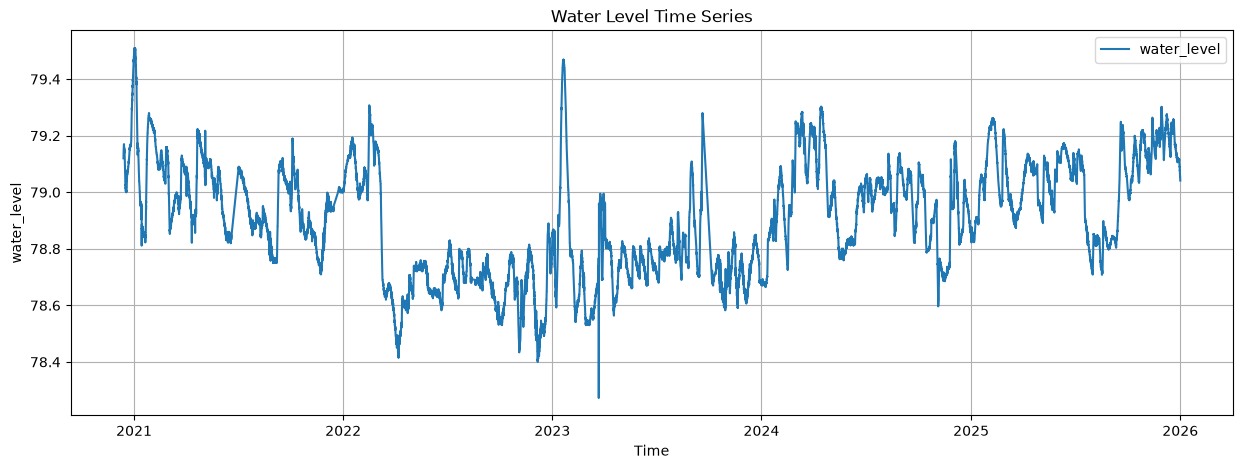

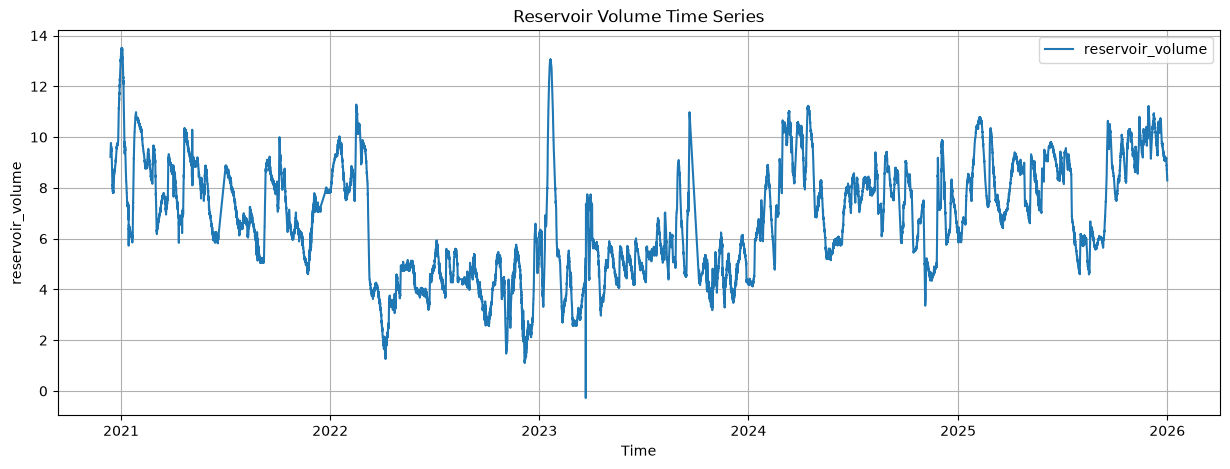

In [49]:
# ============================================================
# 7. Plot raw time series
# ============================================================

plt.figure(figsize=(15, 5))
plt.plot(df[DATE_COL], df[TARGET_COL], label=TARGET_COL)
plt.xlabel("Time")
plt.ylabel(TARGET_COL)
plt.title("Water Level Time Series")
plt.grid(True)
plt.legend()
plt.show()

if RESERVOIR_COL in df.columns:
    plt.figure(figsize=(15, 5))
    plt.plot(df[DATE_COL], df[RESERVOIR_COL], label=RESERVOIR_COL)
    plt.xlabel("Time")
    plt.ylabel(RESERVOIR_COL)
    plt.title("Reservoir Volume Time Series")
    plt.grid(True)
    plt.legend()
    plt.show()

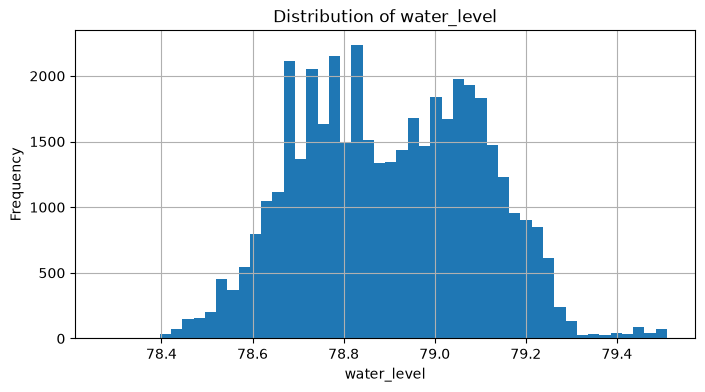

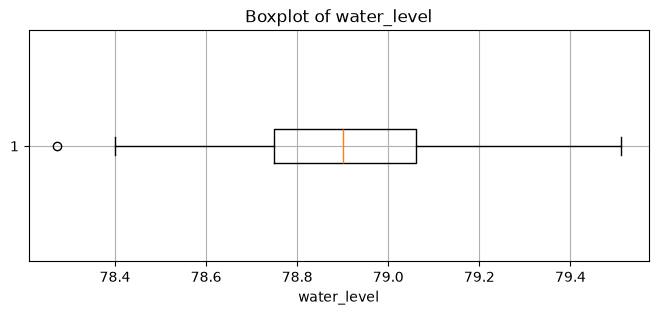

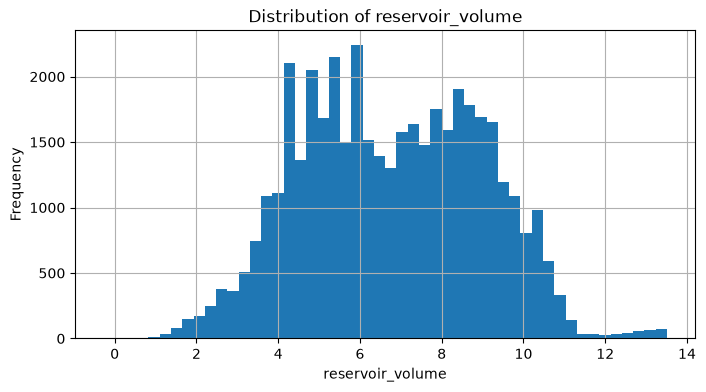

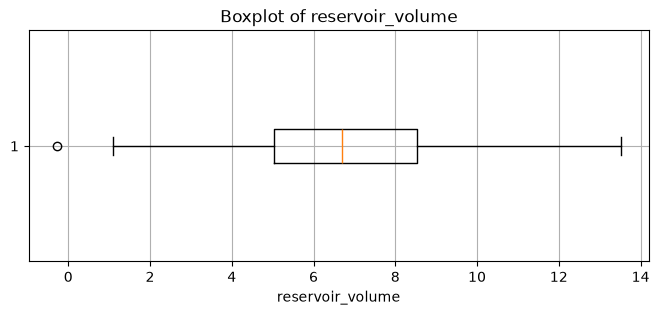

In [50]:
# ============================================================
# 8. Distribution plots
# ============================================================

for col in [TARGET_COL, RESERVOIR_COL]:
    if col not in df.columns:
        continue

    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=50)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")
    plt.grid(True)
    plt.show()

Correlation:


,water_level,reservoir_volume
water_level,1.000000,0.999946
reservoir_volume,0.999946,1.000000


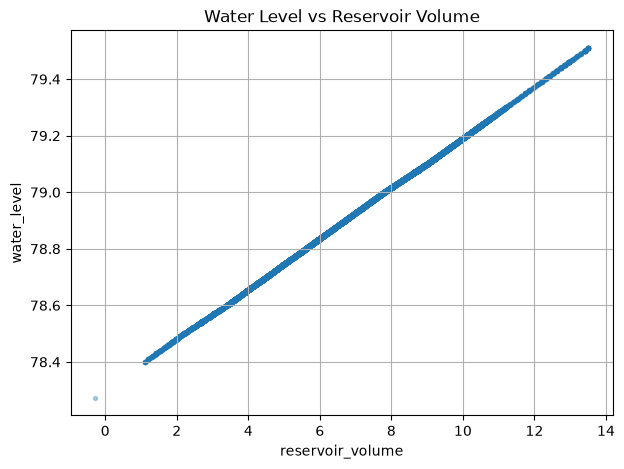

In [51]:
# ============================================================
# 9. Relationship between water level and reservoir volume
# ============================================================

if RESERVOIR_COL in df.columns:
    corr = df[[TARGET_COL, RESERVOIR_COL]].corr()
    print("Correlation:")
    display(corr)

    plt.figure(figsize=(7, 5))
    plt.scatter(df[RESERVOIR_COL], df[TARGET_COL], alpha=0.35, s=8)
    plt.xlabel(RESERVOIR_COL)
    plt.ylabel(TARGET_COL)
    plt.title("Water Level vs Reservoir Volume")
    plt.grid(True)
    plt.show()
else:
    print("Reservoir volume column not available.")

,water_level,reservoir_volume
month,,
1,79.007538,7.922317
2,79.006754,7.924672
3,78.912428,6.861986
4,78.908602,6.824506
5,78.882484,6.527903
6,78.859736,6.276982
7,78.892321,6.632820
8,78.850972,6.168864
9,78.902353,6.749349


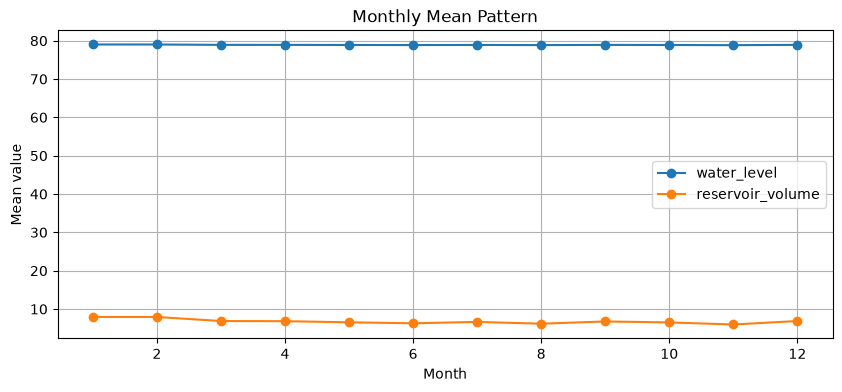

In [52]:
# ============================================================
# 10. Time-based aggregation
# ============================================================

df_eda = df.copy()
df_eda["hour"] = df_eda[DATE_COL].dt.hour
df_eda["month"] = df_eda[DATE_COL].dt.month
df_eda["year"] = df_eda[DATE_COL].dt.year
df_eda["dayofyear"] = df_eda[DATE_COL].dt.dayofyear

monthly = df_eda.groupby("month")[[c for c in [TARGET_COL, RESERVOIR_COL] if c in df_eda.columns]].mean()

display(monthly)

plt.figure(figsize=(10, 4))
for col in monthly.columns:
    plt.plot(monthly.index, monthly[col], marker="o", label=col)
plt.xlabel("Month")
plt.ylabel("Mean value")
plt.title("Monthly Mean Pattern")
plt.grid(True)
plt.legend()
plt.show()

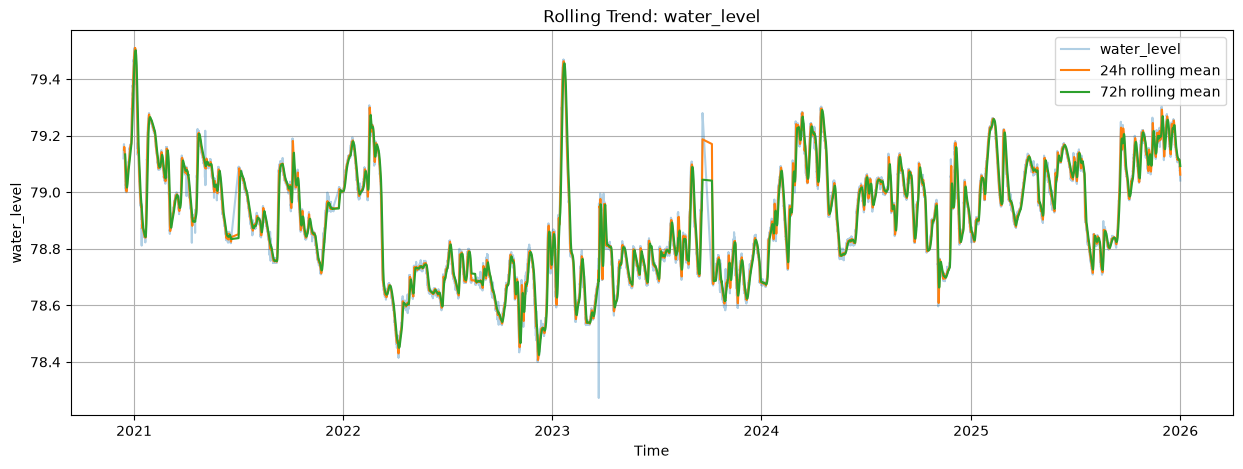

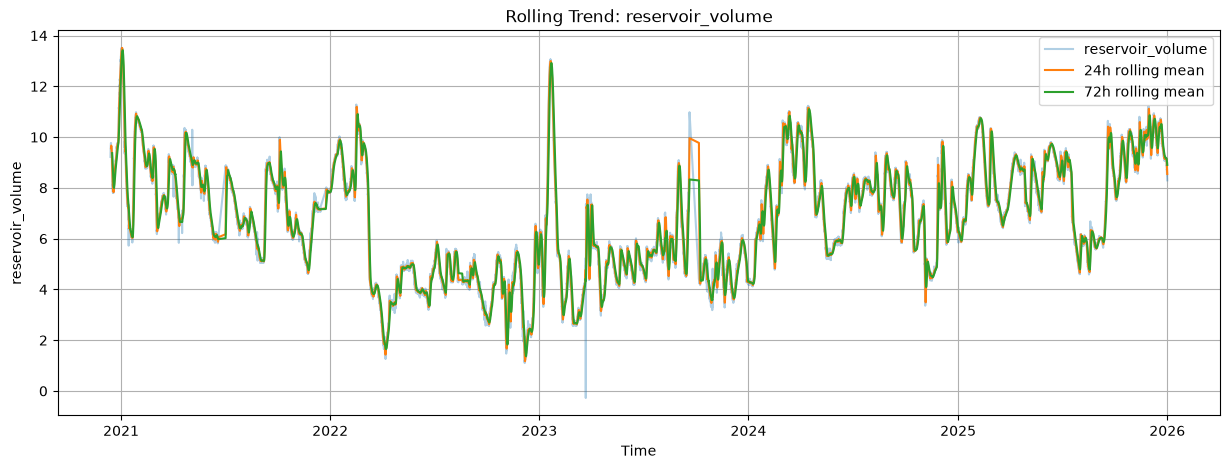

In [53]:
# ============================================================
# 11. Rolling trends
# ============================================================

def hours_to_periods(hours):
    return max(int(round(hours / time_step_hours)), 1)

for col in [TARGET_COL, RESERVOIR_COL]:
    if col not in df.columns:
        continue

    temp = df[[DATE_COL, col]].copy()
    temp[f"{col}_roll_24h"] = temp[col].rolling(hours_to_periods(24)).mean()
    temp[f"{col}_roll_72h"] = temp[col].rolling(hours_to_periods(72)).mean()

    plt.figure(figsize=(15, 5))
    plt.plot(temp[DATE_COL], temp[col], alpha=0.35, label=col)
    plt.plot(temp[DATE_COL], temp[f"{col}_roll_24h"], label="24h rolling mean")
    plt.plot(temp[DATE_COL], temp[f"{col}_roll_72h"], label="72h rolling mean")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.title(f"Rolling Trend: {col}")
    plt.grid(True)
    plt.legend()
    plt.show()

,count,mean,std,min,25%,50%,75%,max
water_level_change_6h,42770.0,-0.000012,0.015265,-0.58000,-0.00748,0.0000,0.006000,0.65000
water_level_change_24h,42752.0,-0.000050,0.037583,-0.58501,-0.01699,-0.0025,0.011672,0.67751
water_level_change_72h,42704.0,-0.000069,0.081393,-0.58999,-0.04001,-0.0075,0.038250,0.67084


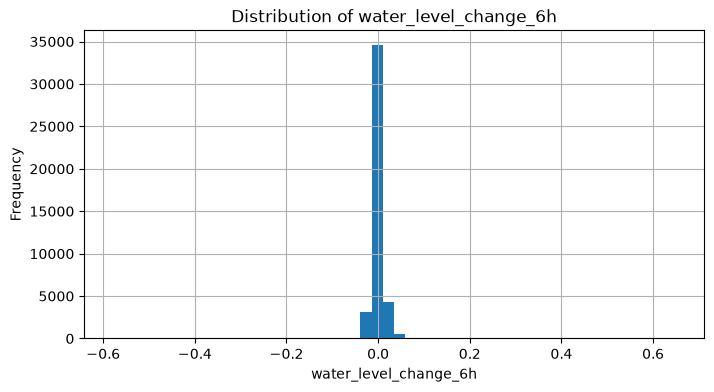

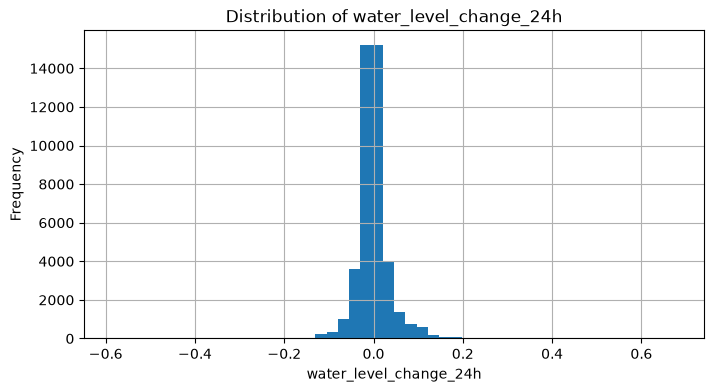

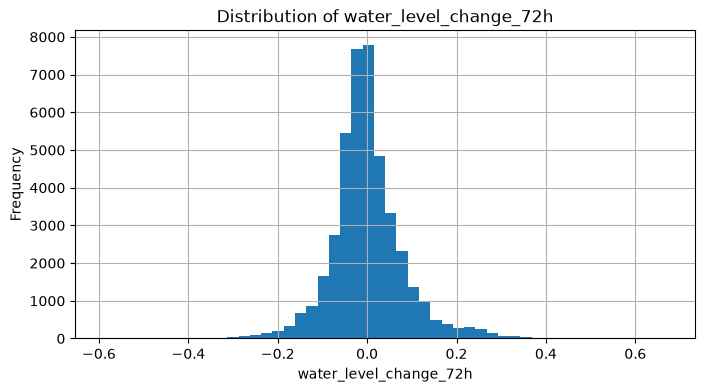

In [54]:
# ============================================================
# 12. Rise/change analysis
# ============================================================

for lag_h in [6, 24, 72]:
    periods = hours_to_periods(lag_h)
    df_eda[f"water_level_change_{lag_h}h"] = df_eda[TARGET_COL] - df_eda[TARGET_COL].shift(periods)

change_cols = [c for c in df_eda.columns if c.startswith("water_level_change_")]
display(df_eda[change_cols].describe().T)

for col in change_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df_eda[col].dropna(), bins=50)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.grid(True)
    plt.show()

Water-level high threshold, 90th percentile: 79.16
Water-level critical threshold, 97th percentile: 79.24


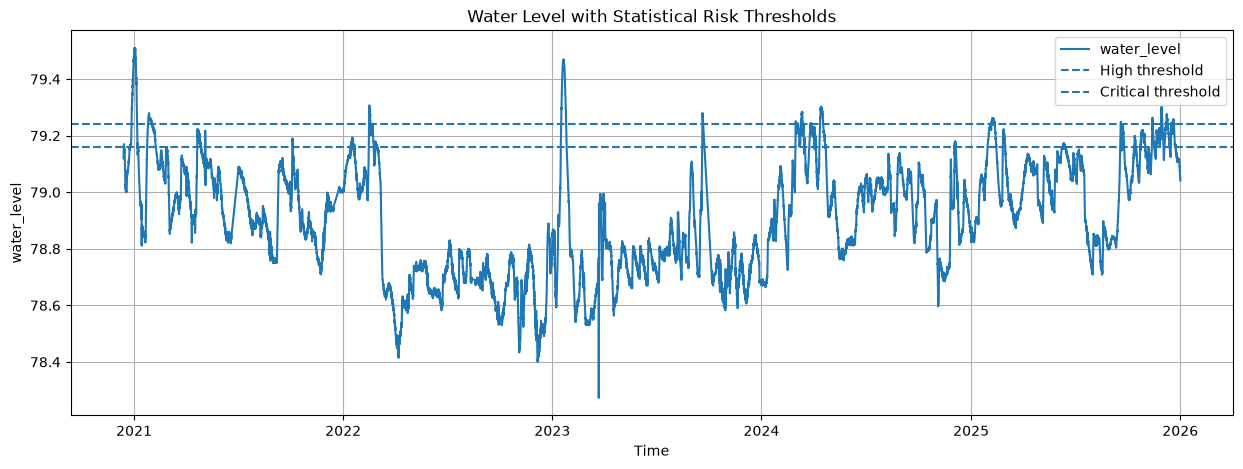

In [55]:
# ============================================================
# 13. Flood-risk proxy thresholds
# ============================================================

level_high = df[TARGET_COL].quantile(0.90)
level_critical = df[TARGET_COL].quantile(0.97)

print("Water-level high threshold, 90th percentile:", level_high)
print("Water-level critical threshold, 97th percentile:", level_critical)

plt.figure(figsize=(15, 5))
plt.plot(df[DATE_COL], df[TARGET_COL], label=TARGET_COL)
plt.axhline(level_high, linestyle="--", label="High threshold")
plt.axhline(level_critical, linestyle="--", label="Critical threshold")
plt.xlabel("Time")
plt.ylabel(TARGET_COL)
plt.title("Water Level with Statistical Risk Thresholds")
plt.grid(True)
plt.legend()
plt.show()

In [56]:
# ============================================================
# 14. Save clean wide data
# ============================================================

save_clean_data(df)

Saved clean wide data to: ../src/data/processed/nve_observations_wide_clean.csv


'../src/data/processed/nve_observations_wide_clean.csv'

## EDA interpretation notes

Use this in your explanation:

- `water_level` is the prediction target.
- `reservoir_volume` is an additional hydrological state feature.
- Repeated metadata in the long CSV is normal; modelling should use the wide CSV.
- The median timestamp gap is used later to correctly convert `6h`, `24h`, and `72h` horizons into dataframe row shifts.
- The flood thresholds here are statistical proxy thresholds, not official NVE warning thresholds.